# Superstore Sales & Profit Analysis

## Business Intelligence Project

**Author:** Ali Qaqour

**Tools:** Python, Pandas, NumPy, Matplotlib

**Dataset:** Sample Superstore Dataset

---

### Project Objective

This project analyzes Superstore sales data to uncover business insights related to sales performance, profitability, customer behavior, and regional trends. The analysis aims to support business investment through data cleaning, exploratory analysis, and visualization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
raw_data = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

In [5]:
data = raw_data.copy()

In [6]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
data.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [9]:
data.shape

(9994, 21)

In [10]:
data.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [11]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [13]:
data.duplicated().sum()

np.int64(0)

In [16]:
data[data.duplicated()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


In [17]:
data.nunique()

Row ID           9994
Order ID         5009
Order Date       1237
Ship Date        1334
Ship Mode           4
Customer ID       793
Customer Name     793
Segment             3
Country             1
City              531
State              49
Postal Code       631
Region              4
Product ID       1862
Category            3
Sub-Category       17
Product Name     1850
Sales            5825
Quantity           14
Discount           12
Profit           7287
dtype: int64

In [20]:
categorical_columns = [
    "Ship Mode",
    "Segment",
    "Country",
    "Region",
    "Category",
    "Sub-Category"]

for i in categorical_columns:
    print(i)
    print(data[i].unique())
    print("-" * 50)

Ship Mode
<ArrowStringArray>
['Second Class', 'Standard Class', 'First Class', 'Same Day']
Length: 4, dtype: str
--------------------------------------------------
Segment
<ArrowStringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str
--------------------------------------------------
Country
<ArrowStringArray>
['United States']
Length: 1, dtype: str
--------------------------------------------------
Region
<ArrowStringArray>
['South', 'West', 'Central', 'East']
Length: 4, dtype: str
--------------------------------------------------
Category
<ArrowStringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str
--------------------------------------------------
Sub-Category
<ArrowStringArray>
[  'Bookcases',      'Chairs',      'Labels',      'Tables',     'Storage',
 'Furnishings',         'Art',      'Phones',     'Binders',  'Appliances',
       'Paper', 'Accessories',   'Envelopes',   'Fasteners',    'Supplies',
    'Machines',     'Copiers']
Le

In [22]:
data[['Order Date', 'Ship Date']].dtypes


Order Date    str
Ship Date     str
dtype: object

In [24]:
data['Order Date']= pd.to_datetime(data['Order Date'], format= '%m/%d/%Y')

data['Ship Date']= pd.to_datetime(data['Ship Date'], format= '%m/%d/%Y')

In [25]:
data[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

In [26]:
data["Order Date"]

0      2016-11-08
1      2016-11-08
2      2016-06-12
3      2015-10-11
4      2015-10-11
          ...    
9989   2014-01-21
9990   2017-02-26
9991   2017-02-26
9992   2017-02-26
9993   2017-05-04
Name: Order Date, Length: 9994, dtype: datetime64[us]

In [27]:
data["Ship Date"]

0      2016-11-11
1      2016-11-11
2      2016-06-16
3      2015-10-18
4      2015-10-18
          ...    
9989   2014-01-23
9990   2017-03-03
9991   2017-03-03
9992   2017-03-03
9993   2017-05-09
Name: Ship Date, Length: 9994, dtype: datetime64[us]

In [33]:
#Creating shipping days Col

data["Shipping Days"] = (data["Ship Date"] - data["Order Date"]).dt.days

In [34]:
data[ ["Order Date", "Ship Date", "Ship Mode", "Shipping Days"]].head(10)

,Order Date,Ship Date,Ship Mode,Shipping Days
0,2016-11-08,2016-11-11,Second Class,3
1,2016-11-08,2016-11-11,Second Class,3
2,2016-06-12,2016-06-16,Second Class,4
3,2015-10-11,2015-10-18,Standard Class,7
4,2015-10-11,2015-10-18,Standard Class,7
5,2014-06-09,2014-06-14,Standard Class,5
6,2014-06-09,2014-06-14,Standard Class,5
7,2014-06-09,2014-06-14,Standard Class,5
8,2014-06-09,2014-06-14,Standard Class,5
9,2014-06-09,2014-06-14,Standard Class,5


In [35]:
data["Shipping Days"].describe()

count    9994.000000
mean        3.958175
std         1.747567
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping Days, dtype: float64

In [36]:
data[data["Shipping Days"]< 0]


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Days


In [37]:
#dropping Row IDs

data = data.drop(columns=['Row ID'])

In [38]:
data.columns

Index(['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID',
       'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Days'],
      dtype='str')

In [39]:
#Extracting some info from dates

data['Order Year'] = data['Order Date'].dt.year
data['Order Month'] = data['Order Date'].dt.month
data['Month Name'] = data['Order Date'].dt.month_name()
data['Order Quarter'] = data['Order Date'].dt.quarter


In [40]:
data[['Order Year', 'Order Month', 'Month Name', 'Order Quarter']].head(10)

,Order Year,Order Month,Month Name,Order Quarter
0,2016,11,November,4
1,2016,11,November,4
2,2016,6,June,2
3,2015,10,October,4
4,2015,10,October,4
5,2014,6,June,2
6,2014,6,June,2
7,2014,6,June,2
8,2014,6,June,2
9,2014,6,June,2


In [41]:
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]

In [48]:
data['Month Name'] = pd.Categorical(data['Month Name'], categories=month_order, ordered=True)

In [50]:
data.shape

(9994, 25)

In [51]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       9994 non-null   str           
 1   Order Date     9994 non-null   datetime64[us]
 2   Ship Date      9994 non-null   datetime64[us]
 3   Ship Mode      9994 non-null   str           
 4   Customer ID    9994 non-null   str           
 5   Customer Name  9994 non-null   str           
 6   Segment        9994 non-null   str           
 7   Country        9994 non-null   str           
 8   City           9994 non-null   str           
 9   State          9994 non-null   str           
 10  Postal Code    9994 non-null   int64         
 11  Region         9994 non-null   str           
 12  Product ID     9994 non-null   str           
 13  Category       9994 non-null   str           
 14  Sub-Category   9994 non-null   str           
 15  Product Name   9994 non-null   s

In [52]:
data.isnull().sum()

Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Shipping Days    0
Order Year       0
Order Month      0
Month Name       0
Order Quarter    0
dtype: int64

In [53]:
data.duplicated().sum()

np.int64(1)

In [58]:
# Remove duplicate records
data = data.drop_duplicates().reset_index(drop=True)

In [62]:
# Verify duplicates have been removed
data.duplicated().sum()

np.int64(0)

In [63]:
data.shape


(9993, 25)

In [64]:
data[["Order Date", "Ship Date"]].dtypes


Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

In [65]:
data["Shipping Days"].describe()

count    9993.000000
mean        3.958171
std         1.747654
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping Days, dtype: float64

In [66]:
#EDA starts here

In [69]:
total_sales = data['Sales'].sum()

In [74]:
total_sales

np.float64(2296919.4883000003)

In [77]:
#formatting

print(F"Total Sales: ${total_sales:,.2f}")

Total Sales: $2,296,919.49


In [81]:
total_profit = data['Profit'].sum()

In [82]:
print(F"Total Profit: ${total_profit:,.2f}")

Total Profit: $286,409.08


In [84]:
#next is number of orders

total_orders = data['Order ID'].nunique()

In [86]:
print(F"Total Orders: {total_orders:,}")

Total Orders: 5,009


In [87]:
total_customers = data['Customer ID'].nunique()

In [88]:
print(F"Total Customers: {total_customers:,}")

Total Customers: 793


In [89]:
average_order_value = total_sales / total_orders

print(f"Average Order Value: ${average_order_value:,.2f}")

Average Order Value: $458.56


In [90]:
#Sales Analysis 

monthly_sales = (data.groupby("Month Name")['Sales'].sum().sort_index())
monthly_sales

Month Name
January       94924.8356
February      59751.2514
March        205005.4888
April        137480.7566
May          155028.8117
June         152718.6793
July         147238.0970
August       159044.0630
September    307649.9457
October      200322.9847
November     352461.0710
December     325293.5035
Name: Sales, dtype: float64

## Monthly Sales Analysis

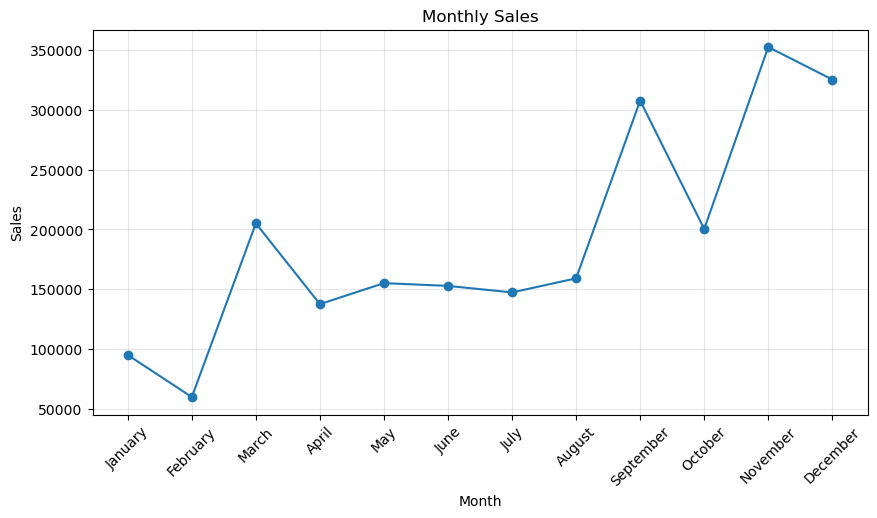

In [92]:
#visualization

plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.show()

### 

- Sales peak in November.
- February records the lowest sales.
- Sales generally increase during the second half of the year.

### Business Recommendation

The company should prepare additional inventory and marketing campaigns before November to capitalize on the increase in demand. Low-performing months such as February should be observed to find out which strategies could improve sales.


In [96]:
category_sales = (data.groupby("Category")['Sales'].sum().sort_values(ascending = False))
category_sales

Category
Technology         836154.0330
Furniture          741718.4233
Office Supplies    719047.0320
Name: Sales, dtype: float64

## Sales by Category

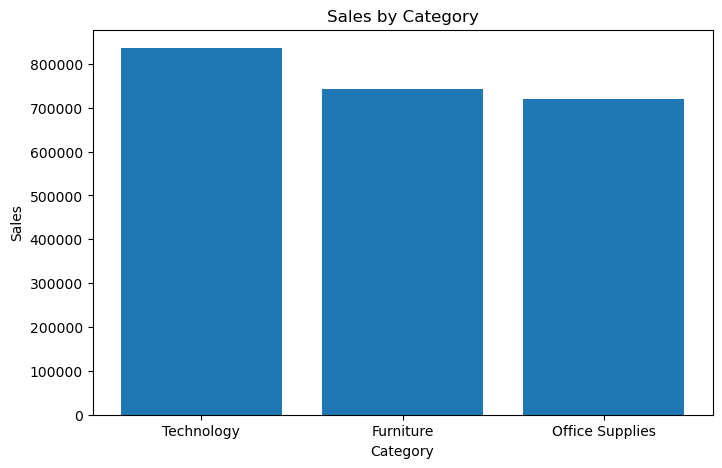

In [97]:
plt.figure(figsize=(8,5))

plt.bar(
    category_sales.index,
    category_sales.values
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

In [102]:
sub_category_sales = (data.groupby("Sub-Category")['Sales'].sum().sort_values(ascending = False))
sub_category_sales

Sub-Category
Phones         330007.0540
Chairs         328167.7310
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64

## Sales by Sub Category

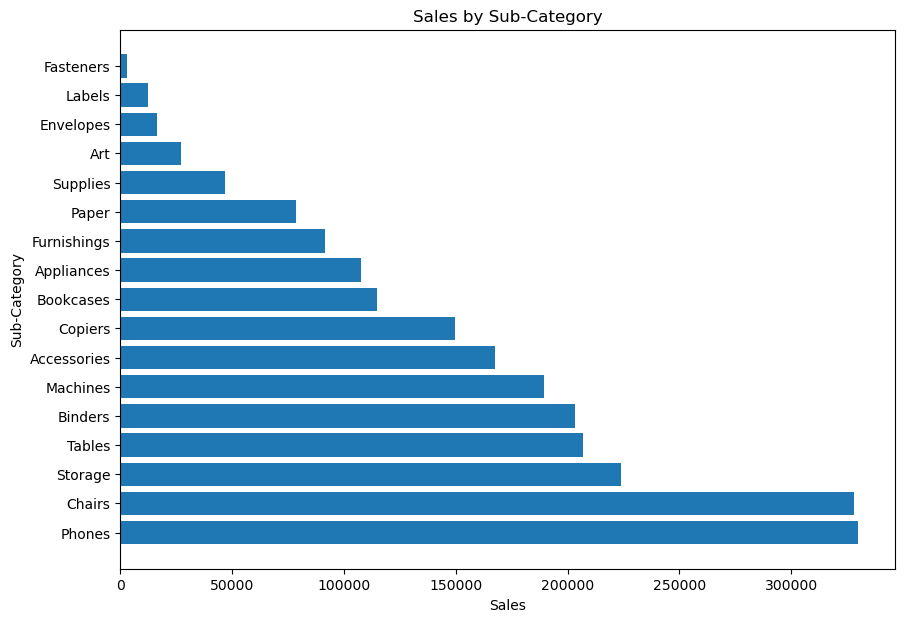

In [105]:
plt.figure(figsize=(10,7))

plt.barh(
    sub_category_sales.index,
    sub_category_sales.values
)

plt.title("Sales by Sub-Category")
plt.xlabel("Sales")
plt.ylabel("Sub-Category")

plt.show()

In [108]:
yearly_sales = (data.groupby("Order Year")['Sales'].sum().sort_index())
yearly_sales

Order Year
2014    483966.1261
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

## Sales by Year

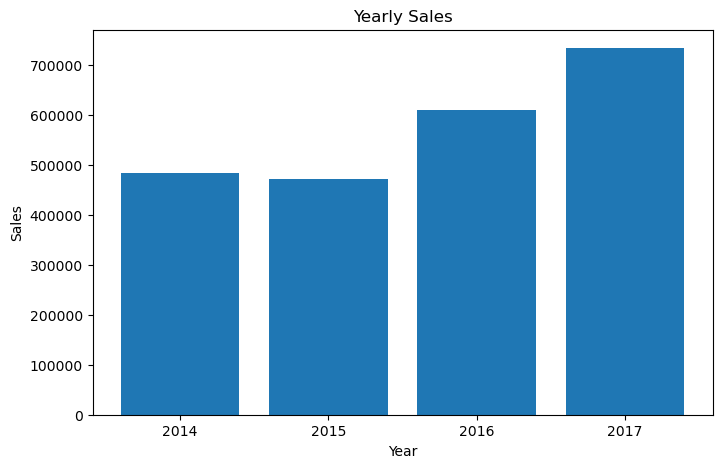

In [109]:
plt.figure(figsize=(8,5))

plt.bar(
    yearly_sales.index.astype(str),
    yearly_sales.values
)

plt.title("Yearly Sales")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.show()

In [111]:
top_customers = (data.groupby("Customer Name")['Sales'].sum().sort_values(ascending = False).head(10))
top_customers

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

### Top 10 Customers

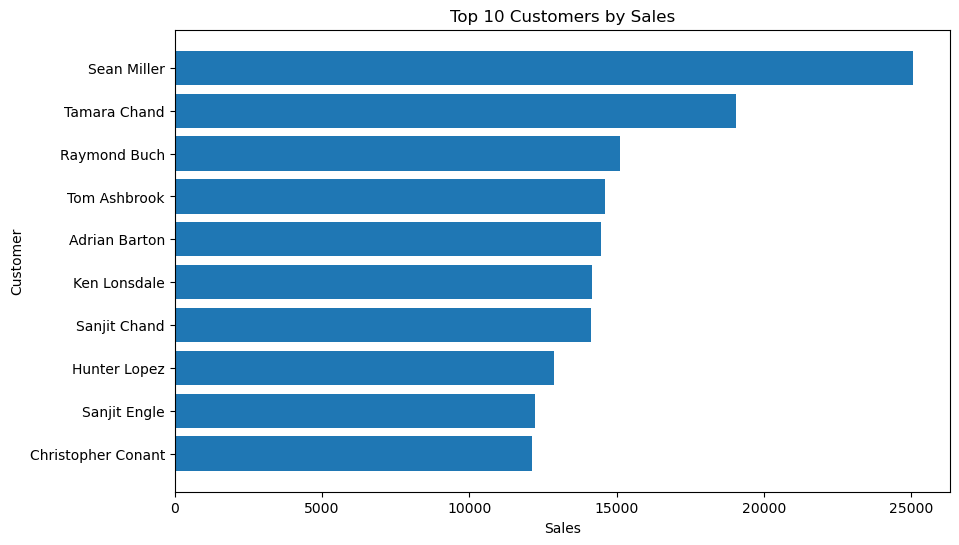

In [112]:
plt.figure(figsize=(10,6))

plt.barh(
    top_customers.index,
    top_customers.values
)

plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales")
plt.ylabel("Customer")

plt.gca().invert_yaxis()

plt.show()

In [113]:
# Profit Analysis starts here

In [114]:
monthly_profit = (data.groupby("Month Name")['Profit'].sum().sort_index())
monthly_profit

Month Name
January       9134.4461
February     10294.6107
March        28594.6872
April        11599.4951
May          22411.3078
June         21285.7954
July         13832.6648
August       21776.9384
September    36857.4753
October      31784.0413
November     35468.4265
December     43369.1919
Name: Profit, dtype: float64

### Profit by Month

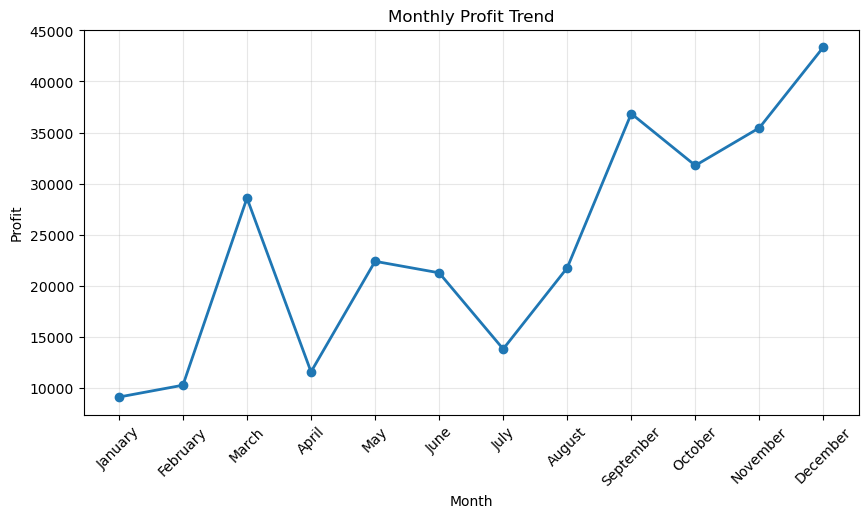

In [119]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_profit.index,
    monthly_profit.values,
    marker="o",
    linewidth=2
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.show()

In [121]:
category_profit = (data.groupby("Category")['Profit'].sum().sort_values(ascending = False))
category_profit

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18463.3316
Name: Profit, dtype: float64

### Profit by Category

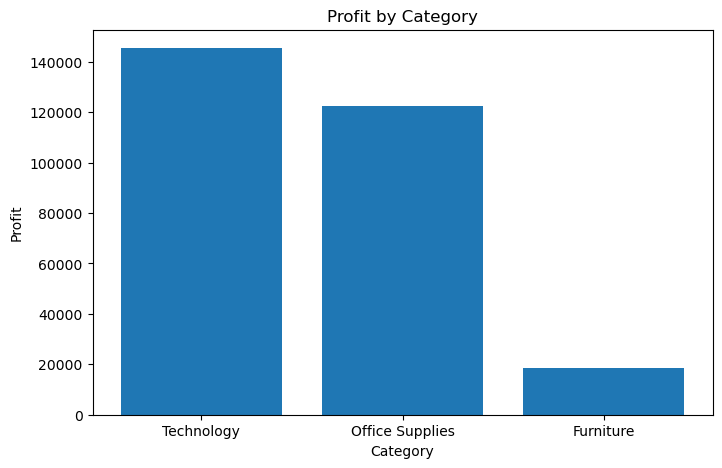

In [122]:
plt.figure(figsize=(8,5))

plt.bar(
    category_profit.index,
    category_profit.values
)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.show()

In [123]:
subcategory_profit = (data.groupby("Sub-Category")['Profit'].sum().sort_values())
subcategory_profit

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Storage        21278.8264
Chairs         26602.2251
Binders        30221.7633
Paper          34053.5693
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64

### Subcategories Profit

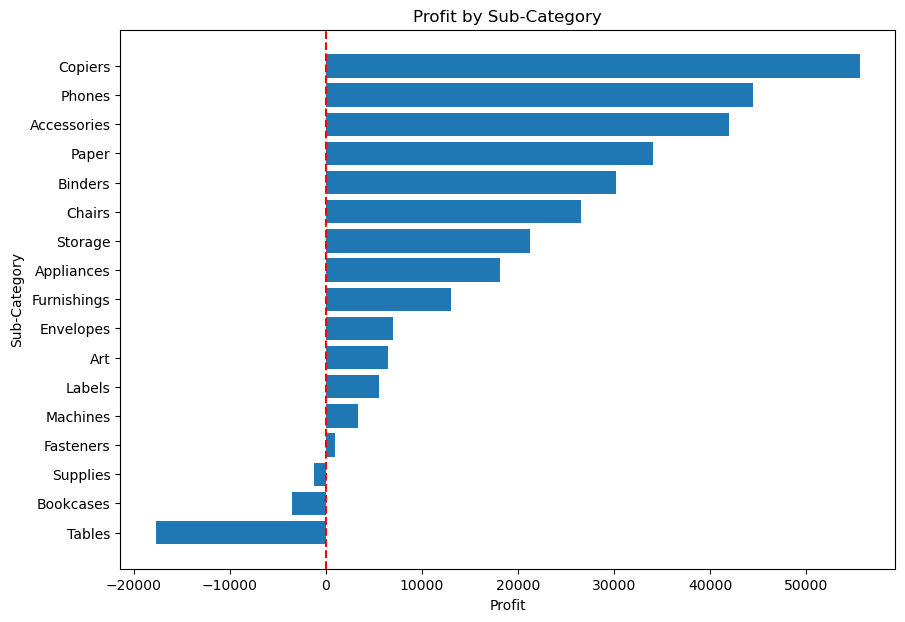

In [124]:
plt.figure(figsize=(10,7))

plt.barh(
    subcategory_profit.index,
    subcategory_profit.values
)

plt.axvline(0, color="red", linestyle="--")

plt.title("Profit by Sub-Category")
plt.xlabel("Profit")
plt.ylabel("Sub-Category")

plt.show()

### The Red Line represets the zero mark, where before it there were no profit and after it there is profit

In [125]:
discount_profit = (data.groupby("Discount")["Profit"].mean())

discount_profit

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.828401
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64

### Profit per Discount (AVG)

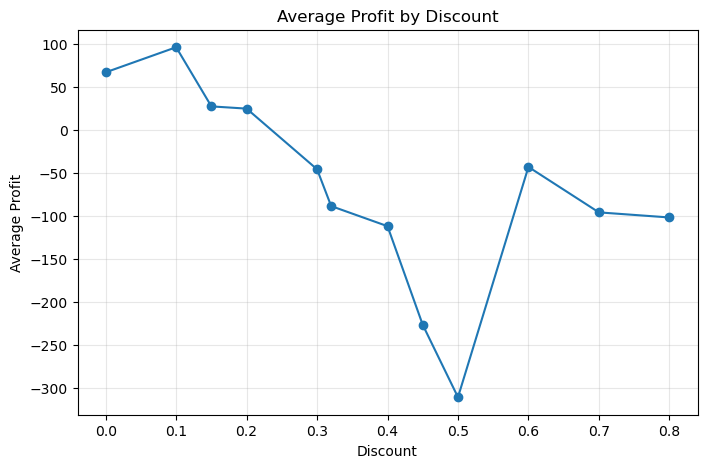

In [127]:
plt.figure(figsize=(8,5))

plt.plot(
    discount_profit.index,
    discount_profit.values,
    marker="o"
)

plt.title("Average Profit by Discount")
plt.xlabel("Discount")
plt.ylabel("Average Profit")

plt.grid(alpha=0.3)

plt.show()

In [130]:
worst_products = (data.groupby("Product Name")["Profit"].sum().sort_values().head(10))

worst_products

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64

### Worst 10 Porducts in Profit

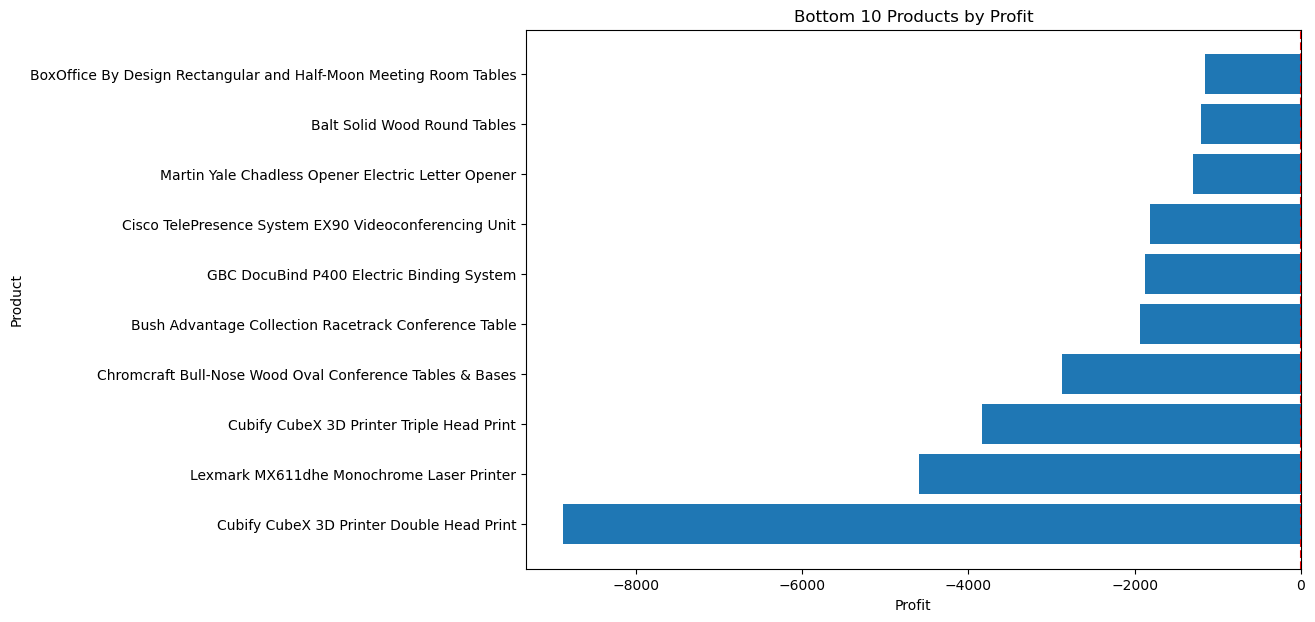

In [132]:
plt.figure(figsize=(10,7))

plt.barh(
    worst_products.index,
    worst_products.values
)

plt.axvline(0, color="red", linestyle="--")

plt.title("Bottom 10 Products by Profit")
plt.xlabel("Profit")
plt.ylabel("Product")

plt.show()

In [133]:
## Customer Analysis now

In [134]:
segment_sales = (data.groupby("Segment")["Sales"].sum().sort_values(ascending = False))
segment_sales

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.293718e+05
Name: Sales, dtype: float64

### Sales per Customer Segment 

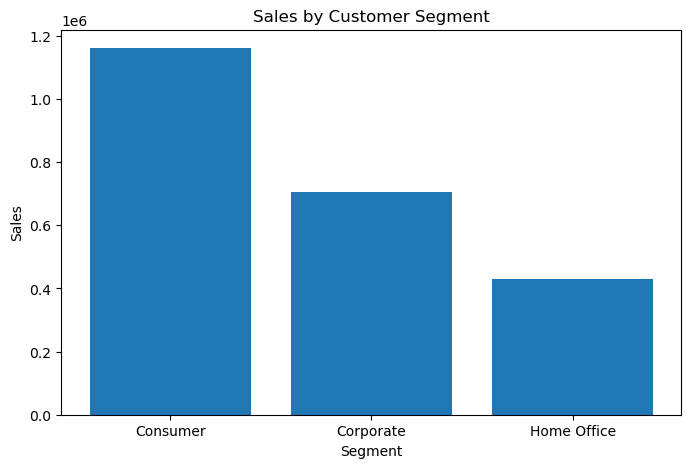

In [136]:
plt.figure(figsize=(8,5))

plt.bar(
    segment_sales.index,
    segment_sales.values
)

plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")

plt.show()

In [137]:
segment_profit = (data.groupby("Segment")["Profit"].sum().sort_values(ascending = False))
segment_profit

Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60310.7373
Name: Profit, dtype: float64

### Profit per Customer Segment 

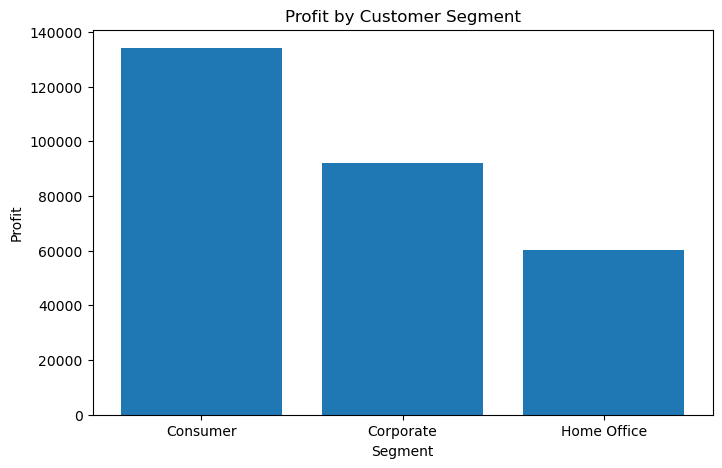

In [139]:
plt.figure(figsize=(8,5))

plt.bar(
    segment_profit.index,
    segment_profit.values
)

plt.title("Profit by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Profit")

plt.show()

In [140]:
top_profit_customers = (data.groupby("Customer Name")["Profit"].sum().sort_values(ascending=False).head(10))

top_profit_customers

Customer Name
Tamara Chand            8981.3239
Raymond Buch            6976.0959
Sanjit Chand            5757.4119
Hunter Lopez            5622.4292
Adrian Barton           5444.8055
Tom Ashbrook            4703.7883
Christopher Martinez    3899.8904
Keith Dawkins           3038.6254
Andy Reiter             2884.6208
Daniel Raglin           2869.0760
Name: Profit, dtype: float64

### Top 10 Customers in Profit

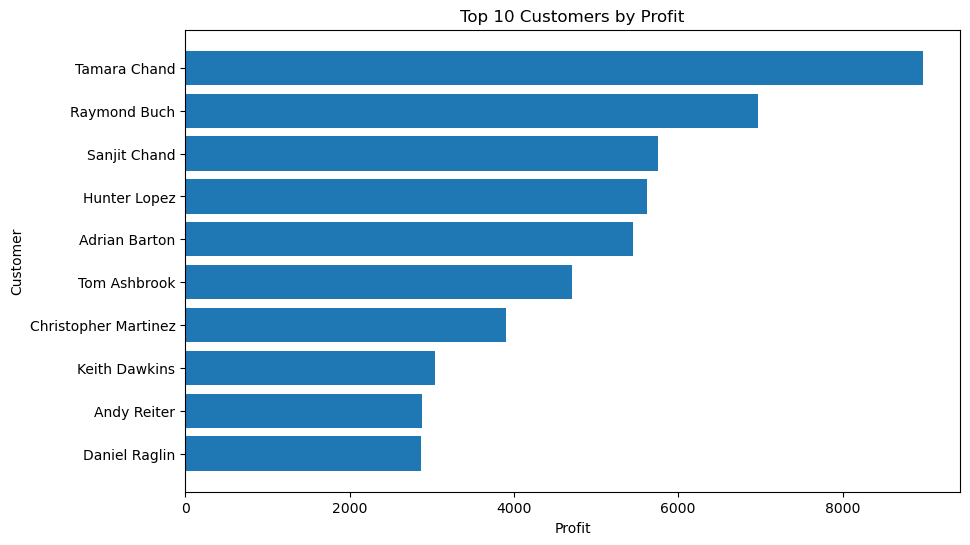

In [145]:
plt.figure(figsize=(10,6))

plt.barh(
    top_profit_customers.index,
    top_profit_customers.values
)

plt.gca().invert_yaxis()

plt.title("Top 10 Customers by Profit")
plt.xlabel("Profit")
plt.ylabel("Customer")

plt.show()

In [146]:
customer_orders = (data.groupby("Customer Name")["Order ID"].nunique().sort_values(ascending=False).head(10))

customer_orders

Customer Name
Emily Phan             17
Sally Hughsby          13
Noel Staavos           13
Patrick Gardner        13
Zuschuss Carroll       13
Joel Eaton             13
Erin Ashbrook          13
Chloris Kastensmidt    13
Suzanne McNair         12
Rick Bensley           12
Name: Order ID, dtype: int64

### Top 10 Customers in Orders

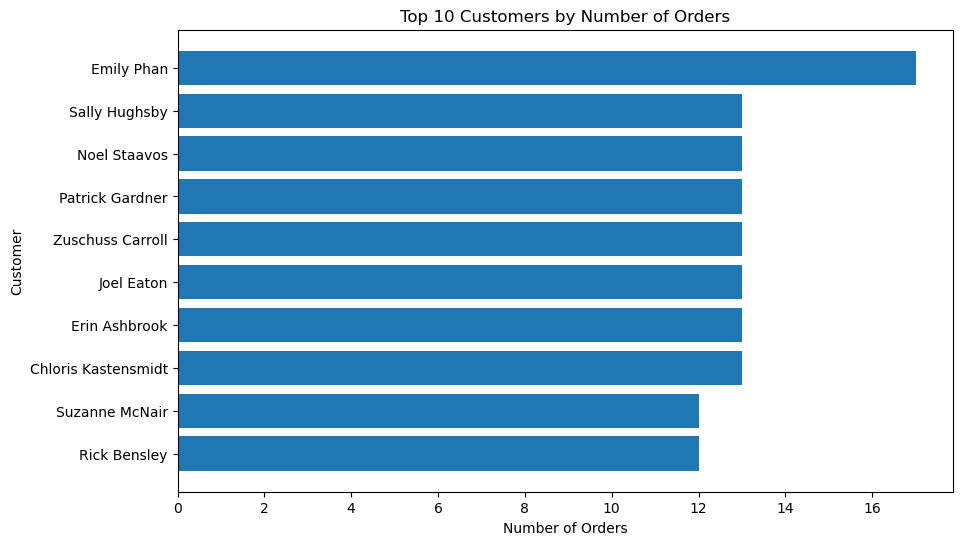

In [148]:
plt.figure(figsize=(10,6))

plt.barh(
    customer_orders.index,
    customer_orders.values
)

plt.gca().invert_yaxis()

plt.title("Top 10 Customers by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Customer")

plt.show()

In [149]:
## Regional Analysis starts here

In [150]:
region_sales = (data.groupby("Region")["Sales"].sum() .sort_values(ascending=False))

region_sales

Region
West       725457.8245
East       678499.8680
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

### Most Sales by Region

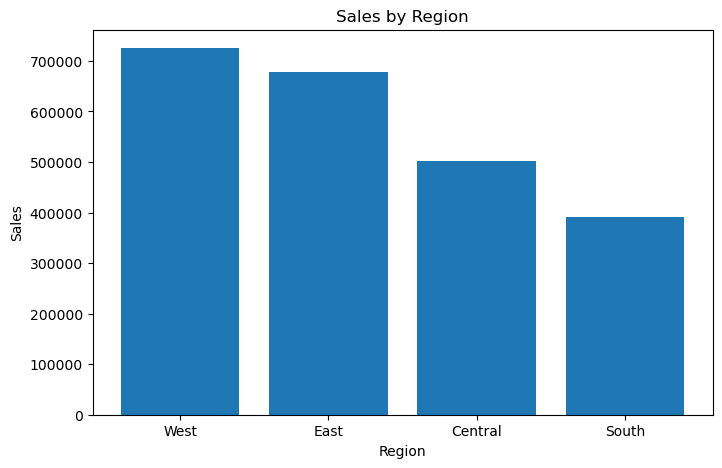

In [152]:
plt.figure(figsize=(8,5))

plt.bar(
    region_sales.index,
    region_sales.values
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

In [153]:
region_profit = (data.groupby("Region")["Profit"].sum().sort_values(ascending=False))

region_profit

Region
West       108418.4489
East        91534.8388
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

### Most Profit by Region

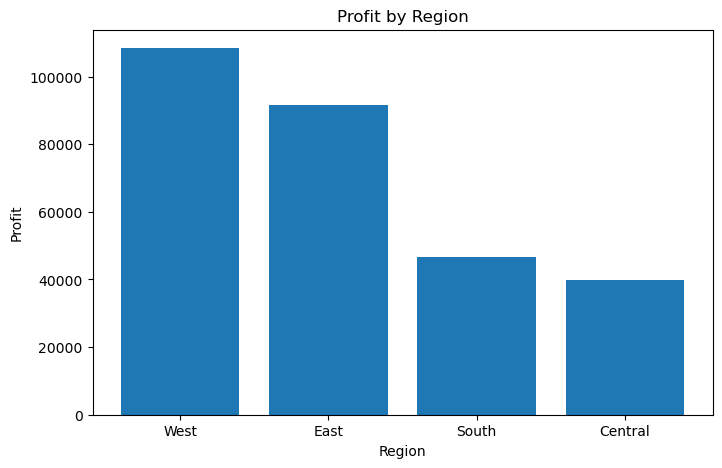

In [154]:
plt.figure(figsize=(8,5))

plt.bar(
    region_profit.index,
    region_profit.values
)

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")

plt.show()

In [157]:
top_states = (data.groupby("State")["Sales"]  .sum()  .sort_values(ascending=False).head(10))

top_states

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             77976.7640
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64

### Top 10 states by Sales

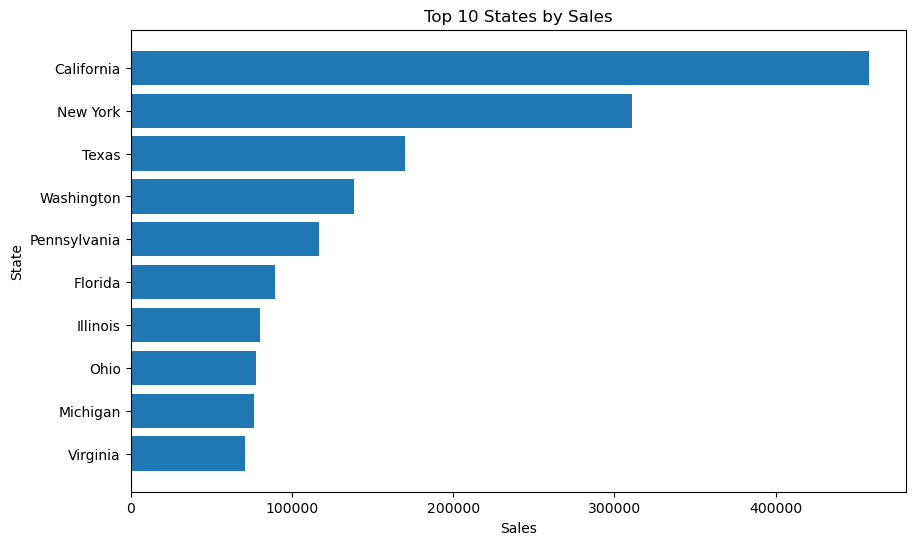

In [158]:
plt.figure(figsize=(10,6))

plt.barh(
    top_states.index,
    top_states.values
)

plt.gca().invert_yaxis()

plt.title("Top 10 States by Sales")
plt.xlabel("Sales")
plt.ylabel("State")

plt.show()

In [159]:
top_profit_states = (data.groupby("State")["Profit"].sum().sort_values(ascending=False).head(10)
)

top_profit_states

State
California    76381.3871
New York      74038.5486
Washington    33402.6517
Michigan      24463.1876
Virginia      18597.9504
Indiana       18382.9363
Georgia       16250.0433
Kentucky      11199.6966
Minnesota     10823.1874
Delaware       9977.3748
Name: Profit, dtype: float64

### Top 10 states by Profit

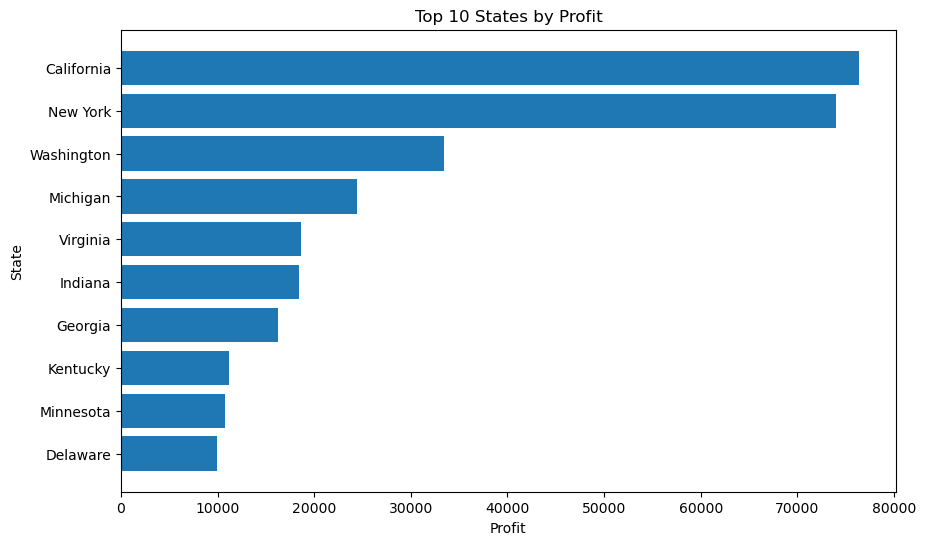

In [160]:
plt.figure(figsize=(10,6))

plt.barh(
    top_profit_states.index,
    top_profit_states.values
)

plt.gca().invert_yaxis()

plt.title("Top 10 States by Profit")
plt.xlabel("Profit")
plt.ylabel("State")

plt.show()

In [161]:
ship_mode = (data["Ship Mode"].value_counts())

ship_mode

Ship Mode
Standard Class    5967
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64

### Most used Shipping Mode

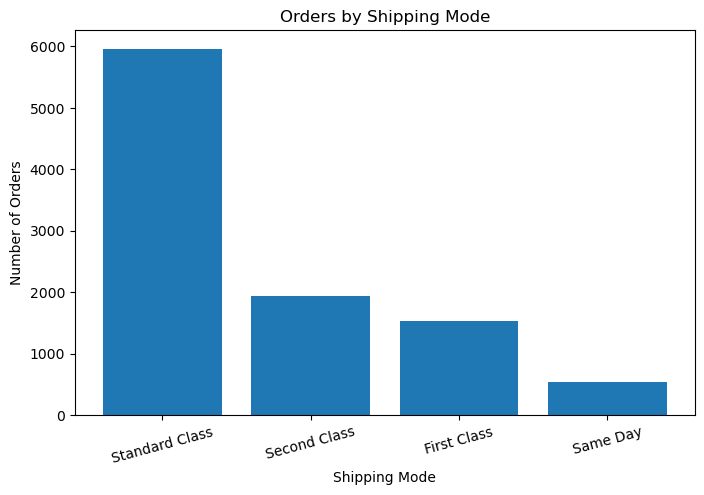

In [162]:
plt.figure(figsize=(8,5))

plt.bar(
    ship_mode.index,
    ship_mode.values
)

plt.title("Orders by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Number of Orders")

plt.xticks(rotation=15)

plt.show()

# Executive Summary

## Key Findings

- Technology generated the highest sales.
- Consumer was the largest customer segment.
- Some sub-categories produced negative profits.
- Higher discounts were associated with lower average profit.
- The West region generated the highest sales and profit.

## Business Recommendations

- Increase investment in high performing categories.
- Review pricing and discount strategies for unprofitable products.
- Focus marketing efforts on high value customer segments.
- Investigate the causes of losses in low profit products and regions.

# Conclusion

This project demonstrates the complete data analysis workflow, from data cleaning and feature engineering to business insight generation and visualization.

The findings provide recommendations that can help improve profitability, optimize sales strategies, and support data-driven decision-making.